<a href="https://colab.research.google.com/github/databyhuseyn/DeepLearning/blob/main/NGrams_BiGram_Name_Generation_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

--2026-05-18 15:28:36--  https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.03s   

2026-05-18 15:28:36 (8.22 MB/s) - ‘names.txt’ saved [228145/228145]



In [2]:
!ls

names.txt  sample_data


In [3]:
with open('names.txt', 'r') as f:
  names = f.read().splitlines()

In [4]:
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
vocab = sorted(list(set(''.join(names))))
vocab

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [6]:
stoi = {char:idx+1 for idx, char in enumerate(vocab)}


In [7]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [8]:
# stoi['<S>'] = 26
# stoi['<E>'] = 27
stoi['.']=0

In [9]:
itos = {idx:char for char, idx in stoi.items()}

In [10]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [11]:
b = {}
for name in names:
  # name = ['<S>'] + list(name) + ['<E>']
  name = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(name, name[1:]):
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1

In [12]:
sorted(b.items(), key=lambda kv:kv[1], reverse=True)

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('.', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '.'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('.', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '.'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('.', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '.'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('.', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('.', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('.', 'l'), 1572),
 (('.', 'c'), 1542),
 (('.', 'e'), 1531),
 (('j', 'a'), 1473),
 (('r', '.'), 1377),
 (('n', 'e'),

In [13]:
import matplotlib.pyplot as plt
import torch

In [14]:
shape = len(stoi)
N = torch.zeros((shape, shape), dtype=torch.int32)
N

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],


In [15]:
for name in names:
  # name = ['<S>'] + list(name) + ['<E>']
  name = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(name, name[1:]):
    idx1 = stoi[ch1]
    idx2 = stoi[ch2]

    N[idx1, idx2] += 1

In [113]:
N = N+1

In [114]:
N.shape

torch.Size([27, 27])

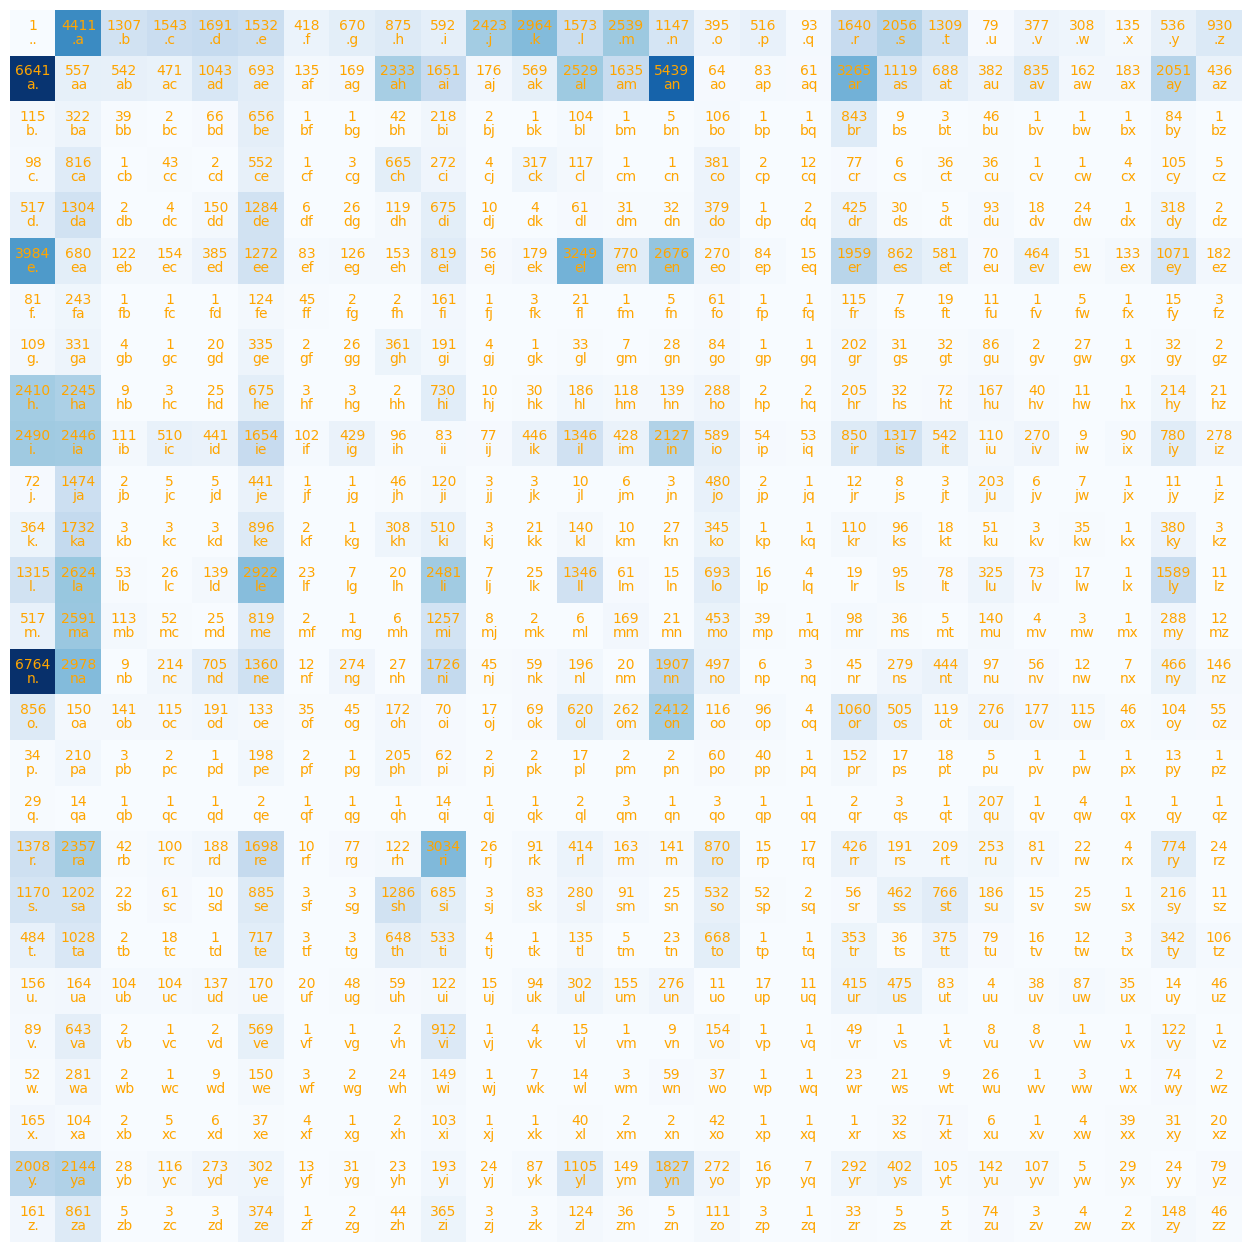

In [115]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(len(stoi)):
  for j in range(len(itos)):
    chrs = itos[i] + itos[j]
    plt.text(j, i, chrs, va='top', ha='center', color='orange')
    plt.text(j, i, N[i, j].item(), va='bottom', ha='center', color='orange')
plt.axis('off')
plt.show()

In [25]:
torch.multinomial(torch.tensor([0.5, 0.4, 0.1]), num_samples=1)

tensor([1])

In [116]:
P = N / N.sum(dim=1, keepdim=True)

In [117]:
P.sum(dim=1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [47]:
torch.multinomial(P[0], num_samples=1)

tensor([1])

In [118]:
g = torch.Generator().manual_seed(42)
def generate_names(n_names: int = 10, generator= None):
  list_of_names = []
  for _ in range(n_names):
    idx = 0
    generated_ids = []
    while True:
      idx = torch.multinomial(P[idx], num_samples=1, replacement=True, generator=generator).item()
      generated_ids.append(idx)
      if idx == 0:
        break
    name = ''.join([itos[element] for element in generated_ids])
    list_of_names.append(name[:-1])

  return list_of_names

In [119]:
g = torch.Generator().manual_seed(42)
generate_names(10, g)

['anugeenvi',
 's',
 'mabidushan',
 'stan',
 'silaylelaremah',
 'li',
 'le',
 'epiachalen',
 'diza',
 'k']

# Evaluation

In [129]:
torch.log(torch.tensor(0.0000001))

tensor(-16.1181)

In [130]:
def calculate_loss(name):
  log_likelihood = 0.
  name = name.lower()
  for ch1, ch2 in zip(name, name[1:]):
    idx1 = stoi[ch1]
    idx2 = stoi[ch2]

    proba = P[idx1, idx2]
    log_likelihood += torch.log(proba)

  nll = log_likelihood * -1
  return nll

In [131]:
name = 'Altay'

calculate_loss(name)

tensor(12.2850)

In [133]:
print(f'Where should loss start: {-torch.log(torch.tensor(1/len(stoi)))}')

Where should loss start: 3.295836925506592


# Neural Network Approach

In [202]:
xs = []
ys = []

for name in names[:1]:
  name = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(name, name[1:]):
    idx1 = stoi[ch1]
    idx2 = stoi[ch2]

    xs.append(idx1)
    ys.append(idx2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [203]:
xs

tensor([ 0,  5, 13, 13,  1])

In [204]:
ys

tensor([ 5, 13, 13,  1,  0])

In [205]:
import torch.nn.functional as F

In [206]:
xenc = F.one_hot(xs, num_classes=len(stoi)).float()

In [207]:
xenc.shape

torch.Size([5, 27])

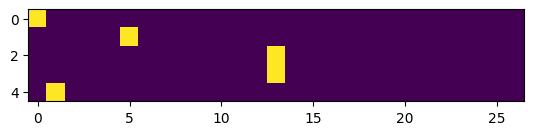

In [208]:
plt.imshow(xenc)

In [209]:
xenc.dtype

torch.float32

In [219]:
shape = xenc.shape[1]

In [221]:
W = torch.randn(size=(shape, shape), requires_grad=True)
outs = xenc @ W

In [222]:
ys

tensor([ 5, 13, 13,  1,  0])

In [223]:
preds = outs.argmax(dim=1, keepdim=True)
preds

tensor([[23],
        [ 6],
        [23],
        [23],
        [ 8]])

In [224]:
[itos[element.item()] for element in preds]

['w', 'f', 'w', 'w', 'h']

In [228]:
loss = F.cross_entropy(outs, ys)
loss

tensor(3.8827, grad_fn=<NllLossBackward0>)

In [229]:
loss

tensor(3.8827, grad_fn=<NllLossBackward0>)

In [230]:
loss.backward()

In [234]:
W.grad

tensor([[ 0.0207,  0.0176,  0.0044,  0.0015,  0.0111, -0.1950,  0.0066,  0.0033,
          0.0271,  0.0018,  0.0059,  0.0056,  0.0031,  0.0024,  0.0146,  0.0024,
          0.0015,  0.0041,  0.0072,  0.0012,  0.0052,  0.0012,  0.0034,  0.0342,
          0.0009,  0.0016,  0.0064],
        [-0.1977,  0.0172,  0.0094,  0.0164,  0.0040,  0.0079,  0.0085,  0.0075,
          0.0221,  0.0131,  0.0061,  0.0034,  0.0033,  0.0006,  0.0021,  0.0028,
          0.0047,  0.0080,  0.0183,  0.0048,  0.0053,  0.0042,  0.0026,  0.0037,
          0.0144,  0.0025,  0.0046],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000